# PRACTICAL SESSION 04

## MODULES IMPORT

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform

# 1 - INPUT GENERATION:

## CHOSING UNITS

In [2]:
# Chosen units (same name as in astropy https://docs.astropy.org/en/stable/units/#module-astropy.units.astrophys)
my_u = ["R_sun","min","M_sun"]

# Physical constants converted to chosen units
G = const.G.to(my_u[0]+"^3/("+my_u[1]+"^2 "+my_u[2]+")").value
c = const.c.to(my_u[0]+"/"+my_u[1]).value
print("G =",G,"c =",c)

# Conversion constants between physical and internal units
R0 = 1.
M0 = 1.
T0 = np.sqrt(R0**3/(G*M0))

G = 0.0014188880292748936 c = 25.855321949116


In [3]:
N = 1000

M = 1
R = 1
U = G * M / R

# Masses
m = M / N * np.ones(N)

# Angular positions
phi = 2 * np.pi * uniform.rvs(size=N)
the = np.arccos(1 - 2 * uniform.rvs(size=N))

# Velocity directions
csi = 2 * np.pi * uniform.rvs(size=N)
zet = np.arccos(1 - 2 * uniform.rvs(size=N))

## POSITION SAMPLING

In [4]:
# Gravitational potential
def psi(r):
  return 1 / np.sqrt(1 + r**2)
# NOTE: the density is proportional to psi^5


# Radius as a function of mass (useful to generate r with the inverse function method)
def radius(M):
  return 1 / np.sqrt(1 / M**(2/3) - 1)

In [5]:
rho = radius(uniform.rvs(size=N))

x = R * rho * np.sin(the) * np.cos(phi)
y = R * rho * np.sin(the) * np.sin(phi)
z = R * rho * np.cos(the)

## VELOCITY SAMPLING

In [6]:
def epsilon(r, v):
    return psi(r) - v**2 / 2

def f(r, v):
    E = epsilon(r, v)
    mask = (E > 0) & (v > 0)
    out = np.zeros(v.shape)
    out[mask] = v[mask]**2 * E[mask]**(7/2)
    return out

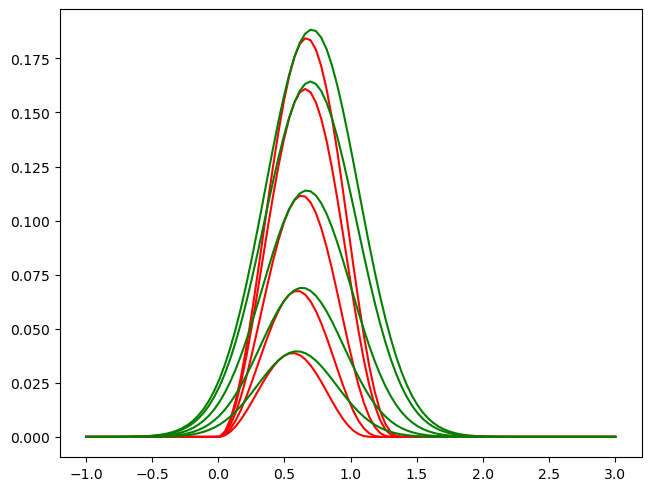

In [7]:
fig, ax = plt.subplots(1, 1, layout='constrained')

r = np.linspace(0, 1, 5)

for i in r:
    v_max = np.sqrt(2 * psi(i))
    x = np.linspace(-1, 3, 100)

    gaus = norm(v_max / 2, v_max / 4)
    k = np.max(f(i, x) / gaus.pdf(x))
    ax.plot(x, f(i, x), color='r')
    ax.plot(x, k * gaus.pdf(x), color='g')

In [8]:
# Very nice implementation (it seems) (retcon: maybe not)

m = 100
vs, r = np.meshgrid(np.linspace(0, 5, m), rho)

k = np.max(f(r, vs) / norm.pdf(vs), axis=1)
__, k = np.meshgrid(np.linspace(0, 5, m), k)

vm = np.sqrt(2 * psi(r))
gaus = norm(vm / 2, vm / 4)

vs = gaus.rvs()
us = uniform.rvs(size=vs.shape)

mask = f(r, vs) / (k * gaus.pdf(vs)) <= us
vs[mask] = -1

#for i in range(N):
    #print(r[i][0], '\t', vs[i][vs[i] >= 0].shape, '\t', vs[i][vs[i] == -1].shape, '\n')

In [9]:
vel = vs

1.3289815062831605

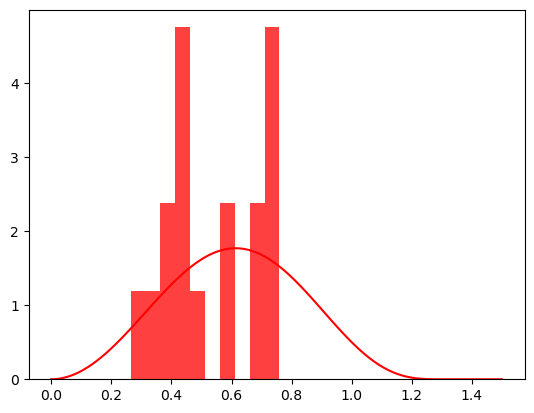

In [10]:
x = np.linspace(0, 1.5, 100)
color = ['r', 'g', 'b', 'yellow', 'orange']

for i in range(1):
    mask = vs[i] >= 0
    bins, edge, patch = plt.hist(vs[i][mask], density=True, alpha=.75, color=color[i])
    plt.plot(x, f(rho[i], x) * bins.sum(), color=color[i])

## PRINT FILE

In [11]:
# FOR TREECODE

m = m / M0

x = x / R0
y = y / R0
z = z / R0

vx = vx / R0 * T0
vy = vy / R0 * T0
vz = vz / R0 * T0

n_dim = 3
time_in = 0 # initial time

out_r = np.column_stack((x, y, z))
out_v = np.column_stack((vx, vy, vz))
with open(file_in, 'w') as file:
    file.write(f'{N}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time_in}\n')
    for i in m:
        file.write(f'{i}\n')
    np.savetxt(file, out_r)
    np.savetxt(file, out_v)

NameError: name 'vx' is not defined